# A Review of AlphaGenome's Ability to Predict Changes in Cancer-associated Gene Variant Expression

In this notebook we evaluate AlphaGenome's RNA-seq scores against cancer-associated gene variants using experimentally observed RNA-seq data from lung cancer tissue samples. The aim of this evaluation is to determine if AlphaGenome can be used to identify cancer vaccine targets that are likely to be poorly expressed.

## Methods

The AlphaGenome model predicts the log-fold change (LFC) in expression between a hg38 reference gene and a variant that gene. To evaluate the model's predictions we use experimental data from a few sources. Firstly we use a VCF file of known cancer-associated genes, along with metadata about them. For each of these genes, we get the median expression of hundreds of experimentally measured RNA-seq assays taken from the GTEx database, this represents our reference gene's expected expression profile. We combine this with RNA-seq data taken from lung cancer tissue (we do not know if this is single-cell or tissue data), this represents our variant's (alt) expression. We then calculate a log-fold change in expression between our reference expression and our variant's (alt) expression. This give us a ground-truth dataset which we can use to validate the performance of our model.

The AlphaGenome model is available through an API, with limited control over the inputs and outputs to the model. The model predicts scores for one ref/alt pair at a time with no support for batch processing, with each variant call taking a couple of seconds, meaning limited throughput. The model predicts lots of assay tracks (ATAC-seq, RNA-seq, etc.) for lots of different biosamples (specific-cells, tissues, etc.) within a 1 million base-pair range centered on your gene of interest. For certain tracks, like RNA-seq, it also predicts scores for all genes found within the 1 million base-pair context, using the hg38 genome as reference. We focus on the scores predicted by the RNA-seq scorer and further restrict the scores to only be for biosamples related to the lungs and the genes of interest. Of the biosamples related to the lungs, we only use two of them, CL:0002553 and UBERON:0008952, representing fibroblasts found in the lungs and bulk lung tissue tracks respectively. It is unclear if the ground-truth RNA-seq was measured from a single-cell or bulk tissue sample, so we assess both model scores. There are also two RNA-seq scorers, one predicts a log-fold change (LFC) in mean expression between the ref and alt genes, where the other predicts the max (Active) expression between the two genes. This also allows us to calculate the models predicted mean expression for each of the ref and alt genes, which isn't actually returned by the AlphaGenome API. In summary, we get four scores from the model for each gene: the LFC score for the fibroblast, the LFC for the lung tissue, the active score for the fibroblast, and the active score for the lung tissue.

One major limitation of the AlphaGenome model is the 1 million base-pair context. The VFC file of cancer associated gene variants contains a DNA sequence of the variant, the chromosome, position, and gene it belongs to, along with DNA sequence of the reference hg38 genome sequence at the same position. However, some genes contain multiple variants. Given that some genes are longer than the 1Mbps context window, the model is unable to attend to all variants within a gene. For the purpose of evaluating the model's performance, we remove all genes that have more than one variant, given that they make up a small fraction of the VCF dataset. Given more time, we would further explore the best way of aggregating scores for genes with multiple variants.

## Results

We begin by exploring the validity of the ground-truth data, see section "[Dataset Generation](#dataset-generation)".

Once we scored all single variant genes, we evaluate the model on the following:
* [What is the relationship between model predictions for genes with ground-truth RNA-seq expression less than 1 TPM vs more than 1 TPM?](#low-expression-vs-high-expression-performance)
* [What is the relationship between model LFC direction predictions and the ground-truth gene variant RNA-seq expression?](#delta-expression-direction-performance)
* [How similar are the model prediction distributions and the ground-truth distributions?](#model-prediction-distributions)
* [How do the model predictions change with the ground-truth data?](#model-predictions-vs-ground-truth-log-fold-change-expression)
* [Is there a score threshold at which the model is able to distinguish between low and high expression genes?](#low-expression-classification-performance)
* [How well do the predicted expression scores for the reference and alternative sequences match the ground truth?](#predicted-rna-seq-reference-vs-alternative-expression-performance)

## Discussion

The model demonstrates robust predictive performance for the expression of individual reference and alternative alleles, a result likely attributable to overfitting to the underlying hg38 reference genome’s expression profile. Given that most genetic variants exert negligible effects on overall expression levels, the model maintains a consistently high correlation with RNA-seq datasets regardless of specific mutations. However, the model struggles to accurately predict the log-fold change in expression of the gene variants, its $1$ Mb genomic context window is insufficient to capture full gene sequences, much less the complex cis-regulatory landscapes essential for accurate expression modeling. The model’s reliance on primary sequence data ignores critical epigenetic information, such as DNA methylation, which serve as primary signals for transcriptional regulation.

Using the RNA-seq active scores for lung tissue track, the model is able to predict when a variant will have a log-fold change in gene expresion more than 1e-3, which can be useful for selecting cancer vaccine candidates that are likely to have some change in gene expression, however the model is unable to determine the direction of change. The model doesn't have the fine-grained ability to understand how small changes to the genome can impact gene expression.

In [320]:
from dotenv import dotenv_values
from pathlib import Path
import pandas as pd
import numpy as np
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from tqdm import tqdm
from alphagenome.data import genome
from alphagenome.models import dna_client, variant_scorers
from sklearn.metrics import accuracy_score, precision_score, recall_score, average_precision_score, matthews_corrcoef
from itertools import batched
import time

PROJECT_ROOT = Path("../")
env_config = dotenv_values(PROJECT_ROOT / ".env")

# Cleaning the VCF Dataset

In [ ]:
# Load VCF genes
vcf_path = PROJECT_ROOT / "data/vcf/TCGA_LUAD.f368273c-bd2d-4b97-97ec-a04cb130af1e.wgs.GATK4_MuTect2_Pair.somatic_annotation.vcf"
vcf_cols = ["CHROM", "POS", "REF", "ALT", "FILTER", "INFO"]
vcf_df = pd.read_csv(vcf_path, sep="\t", comment="#", usecols=vcf_cols)
vcf_df["VARIANT_ID"] = vcf_df["CHROM"] + ":" + vcf_df["POS"].astype("str") + ":" + vcf_df["REF"] + ">" + vcf_df["ALT"]

# Remove non-PASS sequences
pass_mask = vcf_df["FILTER"] == "PASS"
clean_vcf_df = vcf_df[pass_mask].drop(columns=["FILTER"]).reset_index(drop=True)
print(f"Removed non-PASS genes, kept {len(clean_vcf_df)}, removed {sum(~pass_mask)}")

# Get gene id from info
clean_vcf_df[["GENE_ID", "GENE_NAME", "GENE_TYPE", "TRANSCRIPT_ID", "VARIANT_TYPE"]] = clean_vcf_df["INFO"].str.split("|", n=9, expand=True)[[5, 4, 8, 7, 2]]
clean_vcf_df = clean_vcf_df.drop(columns=["INFO"])
clean_vcf_df.columns = clean_vcf_df.columns.str.lower()

# Remove variants that aren't associated with a gene
gene_mask = clean_vcf_df["gene_id"] != ""
clean_vcf_df = clean_vcf_df[gene_mask].reset_index(drop=True)
print(f"Removed missing genes, kept {len(clean_vcf_df)}, removed {sum(~gene_mask)}")

clean_vcf_df

Removed non-PASS genes, kept 2746, removed 1224
Removed missing genes, kept 1864, removed 882


,chrom,pos,ref,alt,variant_id,gene_id,gene_name,gene_type,transcript_id,variant_type
0,chr1,1201562,C,A,chr1:1201562:C>A,ENSG00000186891,TNFRSF18,protein_coding,ENST00000328596,downstream_gene_variant
1,chr1,1229829,C,T,chr1:1229829:C>T,ENSG00000078808,SDF4,protein_coding,ENST00000263741,intron_variant
2,chr1,1559087,C,G,chr1:1559087:C>G,ENSG00000160075,SSU72,protein_coding,ENST00000291386,intron_variant
3,chr1,1892123,T,A,chr1:1892123:T>A,ENSG00000078369,GNB1,protein_coding,ENST00000378609,upstream_gene_variant
4,chr1,2155172,G,A,chr1:2155172:G>A,ENSG00000067606,PRKCZ,protein_coding,ENST00000378567,intron_variant
...,...,...,...,...,...,...,...,...,...,...
1859,chrY,26409485,C,G,chrY:26409485:C>G,ENSG00000188399,ANKRD36P1,unprocessed_pseudogene,ENST00000344424,upstream_gene_variant
1860,chrY,26409534,G,A,chrY:26409534:G>A,ENSG00000188399,ANKRD36P1,unprocessed_pseudogene,ENST00000344424,upstream_gene_variant
1861,chrY,26546090,C,A,chrY:26546090:C>A,ENSG00000215506,TPTE2P4,unprocessed_pseudogene,ENST00000258589,intron_variant&non_coding_transcript_variant
1862,chrY,26546098,A,C,chrY:26546098:A>C,ENSG00000215506,TPTE2P4,unprocessed_pseudogene,ENST00000258589,intron_variant&non_coding_transcript_variant


# Cleaning the RNA-Seq Dataset

In [3]:
# Load RNA-seq dataset
rna_path = PROJECT_ROOT / "data/EXAMPLE RNA.xlsx"
rna_df = pd.read_excel(rna_path, skiprows=1)[4:].drop(columns=["unstranded", "stranded_first", "stranded_second", "fpkm_unstranded", "fpkm_uq_unstranded"])

# Remove non-transcribed genes
valid_types = {
    "protein_coding", 
    "translated_processed_pseudogene", 
    "translated_unprocessed_pseudogene",
    "transcribed_unitary_pseudogene",
    "transcribed_processed_pseudogene",
    "transcribed_unprocessed_pseudogene",
    "lncRNA",
}
gene_mask = rna_df["gene_type"].isin(valid_types)
clean_rna_df = rna_df[gene_mask].reset_index(drop=True)
print(f"Removed non-translated gene types, kept {len(clean_rna_df)}, removed {sum(~gene_mask)}")

# Remove PAR_Y genes as they aren't in the VCF
par_mask = clean_rna_df["gene_id"].str.contains("PAR")
clean_rna_df = clean_rna_df[~par_mask].reset_index(drop=True)
print(f"Removed _PAR_Y genes, kept {len(clean_rna_df)}, removed {sum(par_mask)}")

# Clean up columns
clean_rna_df = clean_rna_df.rename(columns={"gene_id": "version_id", "tpm_unstranded": "tpm"})
clean_rna_df["gene_id"] = clean_rna_df["version_id"].str.split('.', n=1).str[0]

# Remove measurements we don't have VCF variants for
vcf_genes = set(clean_vcf_df["gene_id"].unique())
gene_mask = clean_rna_df["gene_id"].isin(vcf_genes)
clean_rna_df = clean_rna_df[gene_mask].reset_index(drop=True)
print(f"Removed measurements outside of VCF, kept {len(clean_rna_df)}, removed {sum(~gene_mask)}")

clean_rna_df

Removed non-translated gene types, kept 38443, removed 22217
Removed _PAR_Y genes, kept 38412, removed 31
Removed measurements outside of VCF, kept 1479, removed 36933


,version_id,gene_name,gene_type,tpm,gene_id
0,ENSG00000002016.18,RAD52,protein_coding,7.2825,ENSG00000002016
1,ENSG00000002746.15,HECW1,protein_coding,0.3620,ENSG00000002746
2,ENSG00000002822.15,MAD1L1,protein_coding,0.2275,ENSG00000002822
3,ENSG00000003393.15,ALS2,protein_coding,10.0030,ENSG00000003393
4,ENSG00000004700.16,RECQL,protein_coding,17.7617,ENSG00000004700
...,...,...,...,...,...
1474,ENSG00000287948.1,AC084741.1,lncRNA,0.0000,ENSG00000287948
1475,ENSG00000287998.1,AC104232.3,lncRNA,0.8845,ENSG00000287998
1476,ENSG00000287999.1,AC097522.2,lncRNA,0.0000,ENSG00000287999
1477,ENSG00000288571.1,AL442063.1,lncRNA,0.0495,ENSG00000288571


# Download GTEx baselines

In [4]:
def get_gtex_expression(gene_ids, batch_size: int = 250, delay: float = 0.1) -> pd.DataFrame:
    results = []
    for batch in tqdm(batched(gene_ids, batch_size)):
        # Get latest gencode id
        resp = requests.get(
            "https://gtexportal.org/api/v2/reference/gene",
            params={"gencodeVersion": "v39", "geneId": batch}
        )
        resp.raise_for_status()
        batch_metadata = resp.json()["data"]
        batch_gencode_ids = [entry["gencodeId"] for entry in batch_metadata if "PAR" not in entry["gencodeId"]] # Skip PAR_Y entries
        # Get median gene expression using updated id
        resp = requests.get(
            "https://gtexportal.org/api/v2/expression/medianGeneExpression",
            params={"datasetId": "gtex_v10", "gencodeId": batch_gencode_ids, "tissueSiteDetailId": "Lung"}
        )
        resp.raise_for_status()
        batch_expression = resp.json()["data"]
        results.extend(batch_expression)
        time.sleep(delay)

    return pd.DataFrame(results)

gtex_df = get_gtex_expression(clean_rna_df["gene_id"].to_list())
clean_gtex_df = gtex_df.rename(columns={"gencodeId": "version_id", "median": "tpm"})
clean_gtex_df["gene_id"] = clean_gtex_df["version_id"].str.split('.', n=1).str[0]
clean_gtex_df = clean_gtex_df[["gene_id", "version_id", "tpm"]]
clean_gtex_df

6it [00:48,  8.13s/it]


,gene_id,version_id,tpm
0,ENSG00000078808,ENSG00000078808.19,167.509000
1,ENSG00000078369,ENSG00000078369.18,256.301000
2,ENSG00000067606,ENSG00000067606.17,20.249500
3,ENSG00000097021,ENSG00000097021.20,19.546300
4,ENSG00000049239,ENSG00000049239.13,47.187300
...,...,...,...
1459,ENSG00000259849,ENSG00000259849.2,0.000000
1460,ENSG00000281566,ENSG00000281566.3,0.000000
1461,ENSG00000286072,ENSG00000286072.1,0.000000
1462,ENSG00000287918,ENSG00000287918.2,0.094212


# Score The Cancer Associated Genes with AlphaGenome

In [5]:
def request_alpha_genome_scores(variants_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    dna_model = dna_client.create(env_config["ALPHA_GENOME_KEY"])
    tracks_df = dna_model.output_metadata(dna_client.Organism.HOMO_SAPIENS).concatenate()
    tracks_df.columns = ["_".join(col.lower().split(" "))for col in tracks_df.columns]
    organism = dna_client.Organism.HOMO_SAPIENS
    seq_len = dna_client.SUPPORTED_SEQUENCE_LENGTHS['SEQUENCE_LENGTH_1MB']
    score_ids = ['ATAC', 'DNASE', 'CHIP_TF', 'CHIP_HISTONE', 'CAGE', 'PROCAP', 'RNA_SEQ', 'RNA_SEQ_ACTIVE']
    recommended_scorers = variant_scorers.RECOMMENDED_VARIANT_SCORERS
    scorers = [
        recommended_scorers[scorer_id]
        for scorer_id in score_ids
        if organism.value in variant_scorers.SUPPORTED_ORGANISMS[recommended_scorers[scorer_id].base_variant_scorer]
    ]
    columns = ["variant_id", "gene_id", "scored_interval", "ontology_curie", "track_name", "track_strand", "variant_scorer", "raw_score", "quantile_score"]
    batches = []
    for row in tqdm(variants_df.itertuples()):
        variant = genome.Variant(
            chromosome=str(row.chrom),
            position=int(row.pos),
            reference_bases=row.ref,
            alternate_bases=row.alt,
            name=row.variant_id,
        )
        interval = variant.reference_interval.resize(seq_len)
        variant_scores = dna_model.score_variant(
            interval=interval,
            variant=variant,
            variant_scorers=scorers,
            organism=organism,
        )
        batch_df = variant_scorers.tidy_scores(variant_scores)
        gene_mask = batch_df["gene_id"].isna() | (batch_df["gene_id"] == row.gene_id)
        lung_mask = batch_df["biosample_name"].str.lower().str.contains("lung")
        rna_mask = (batch_df["output_type"] != "RNA_SEQ") | (batch_df["track_strand"] == ".")
        batch_df = batch_df.loc[gene_mask & lung_mask & rna_mask, columns]
        batch_df["gene_id"] = row.gene_id
        batch_df["variant_id"] = batch_df["variant_id"].apply(str)
        batch_df["scored_interval"] = batch_df["scored_interval"].apply(str)
        batch_df["aggregation_type"] = batch_df["variant_scorer"].str.extract(r"aggregation_type=([A-Z\d_]*)")
        batch_df["aggregation_type"] = batch_df["aggregation_type"].fillna("NONE")
        batch_df["variant_scorer"] = batch_df["variant_scorer"].str.extract(r"^(\w*)\(")
        batch_df["score_id"] = batch_df["track_name"] + " " + batch_df["track_strand"] + " " + batch_df["variant_scorer"] + " " + batch_df["aggregation_type"]
        batches.append(batch_df)

    return pd.concat(batches, ignore_index=True), tracks_df

In [269]:
scores_path = PROJECT_ROOT / "data/alpha_genome_scores.feather"
tracks_path = PROJECT_ROOT / "data/alpha_genome_tracks.csv"
if scores_path.exists():
    alpha_scores_df = pd.read_feather(scores_path)
    tracks_df = pd.read_csv(tracks_path)
else:
    alpha_scores_df, tracks_df = request_alpha_genome_scores(clean_vcf_df)
    alpha_scores_df.to_feather(scores_path)
    tracks_df.to_csv(tracks_path, index=False)

alpha_scores_df

,variant_id,gene_id,scored_interval,ontology_curie,track_name,track_strand,variant_scorer,raw_score,quantile_score,aggregation_type,score_id
0,chr1:1201562:C>A,ENSG00000186891,chr1:677274-1725850:.,UBERON:0002048,UBERON:0002048 ATAC-seq,.,CenterMaskScorer,-0.149620,-0.984028,DIFF_LOG2_SUM,UBERON:0002048 ATAC-seq . CenterMaskScorer DIF...
1,chr1:1201562:C>A,ENSG00000186891,chr1:677274-1725850:.,UBERON:0002168,UBERON:0002168 ATAC-seq,.,CenterMaskScorer,-0.129393,-0.966109,DIFF_LOG2_SUM,UBERON:0002168 ATAC-seq . CenterMaskScorer DIF...
2,chr1:1201562:C>A,ENSG00000186891,chr1:677274-1725850:.,UBERON:0002170,UBERON:0002170 ATAC-seq,.,CenterMaskScorer,-0.119710,-0.974781,DIFF_LOG2_SUM,UBERON:0002170 ATAC-seq . CenterMaskScorer DIF...
3,chr1:1201562:C>A,ENSG00000186891,chr1:677274-1725850:.,UBERON:0002171,UBERON:0002171 ATAC-seq,.,CenterMaskScorer,-0.087047,-0.966109,DIFF_LOG2_SUM,UBERON:0002171 ATAC-seq . CenterMaskScorer DIF...
4,chr1:1201562:C>A,ENSG00000186891,chr1:677274-1725850:.,UBERON:0008952,UBERON:0008952 ATAC-seq,.,CenterMaskScorer,-0.112170,-0.982497,DIFF_LOG2_SUM,UBERON:0008952 ATAC-seq . CenterMaskScorer DIF...
...,...,...,...,...,...,...,...,...,...,...,...
145283,chrY:26620464:G>C,ENSG00000237917,chrY:26096176-27144752:.,UBERON:0008952,UBERON:0008952 gtex Lung polyA plus RNA-seq,.,GeneMaskLFCScorer,-0.000737,-0.459003,NONE,UBERON:0008952 gtex Lung polyA plus RNA-seq . ...
145284,chrY:26620464:G>C,ENSG00000237917,chrY:26096176-27144752:.,CL:0002553,CL:0002553 polyA plus RNA-seq,.,GeneMaskActiveScorer,0.000086,0.343888,NONE,CL:0002553 polyA plus RNA-seq . GeneMaskActive...
145285,chrY:26620464:G>C,ENSG00000237917,chrY:26096176-27144752:.,UBERON:0002167,UBERON:0002167 polyA plus RNA-seq,.,GeneMaskActiveScorer,0.002065,0.318348,NONE,UBERON:0002167 polyA plus RNA-seq . GeneMaskAc...
145286,chrY:26620464:G>C,ENSG00000237917,chrY:26096176-27144752:.,UBERON:0002168,UBERON:0002168 polyA plus RNA-seq,.,GeneMaskActiveScorer,0.000971,0.313362,NONE,UBERON:0002168 polyA plus RNA-seq . GeneMaskAc...


# Dataset Generation

In [159]:
# Calculate LFC and Active scores for ground-truth
targets_df = clean_rna_df[["gene_id", "tpm"]].merge(clean_gtex_df[["gene_id", "tpm"]], on="gene_id", how="inner", suffixes=["_rna", "_gtex"])
targets_df["delta_tpm"] = np.log2(targets_df["tpm_rna"] + 0.001) - np.log2(targets_df["tpm_gtex"] + 0.001)
targets_df["active_tpm"] = np.maximum(targets_df["tpm_rna"], targets_df["tpm_gtex"])

# Split dataset into genes with single variants vs multiple variants
variant_counts = targets_df.merge(alpha_scores_df, on="gene_id", how="inner").groupby("gene_id")["variant_id"].nunique()
single_gene_set = set(variant_counts[variant_counts <= 1].index)
targets_df = targets_df[targets_df["gene_id"].isin(single_gene_set)].reset_index(drop=True)

### RNA-seq Variant Expression vs GTEx Reference Expression

In [160]:
pg.corr(targets_df["tpm_rna"], targets_df["tpm_gtex"], method="pearson")

,n,r,CI95,p_val,BF10,power
pearson,1273,0.953684,"[0.95, 0.96]",0.0,inf,1.0


We can see that the RNA-seq and GTEx measurements are highly correlated.
This is expected as the variants should only have a small impact in the RNA-seq data.

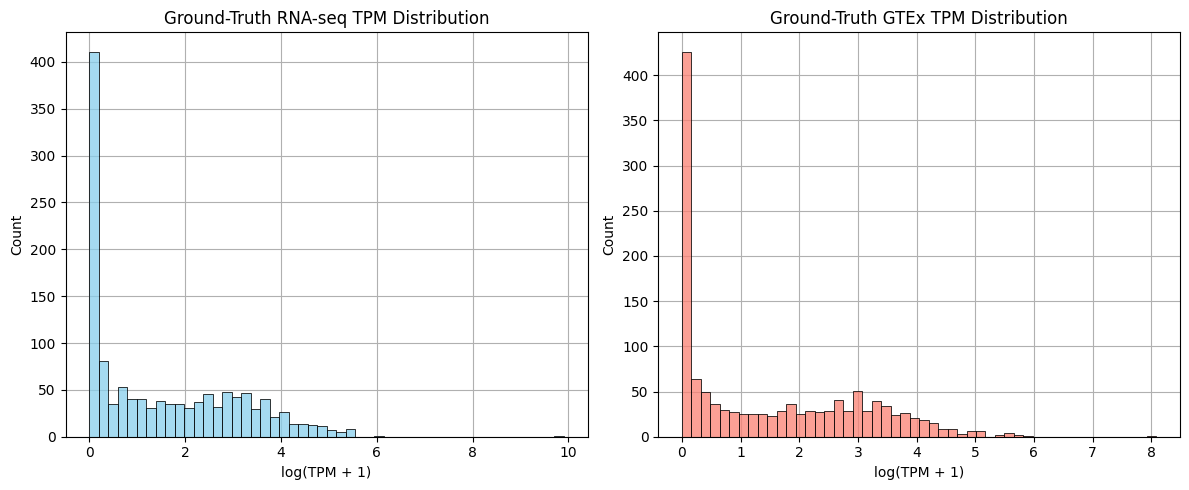

In [179]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(np.log1p(targets_df["tpm_rna"]), bins=50, color="skyblue", edgecolor='black', ax=ax1)
ax1.set_title("Ground-Truth RNA-seq TPM Distribution")
ax1.set_xlabel("log(TPM + 1)")
ax1.set_ylabel("Count")
ax1.grid()
ax1.set_axisbelow(True)

sns.histplot(np.log1p(targets_df["tpm_gtex"]), bins=50, color="salmon", edgecolor='black', ax=ax2)
ax2.set_title("Ground-Truth GTEx TPM Distribution")
ax2.set_xlabel("log(TPM + 1)")
ax2.set_ylabel("Count")
ax2.grid()
ax2.set_axisbelow(True)

plt.tight_layout() # Adjusts spacing so labels don't overlap
plt.show()

### Figure 1.
The left plot shows the ground-truth log TPM distribution of the RNA-seq variant gene expression, demonstrating the classic multi-modal log1p TPM distribution.
The right plot shows the ground-truth log TPM distribution of the GTEx median reference gene expression.

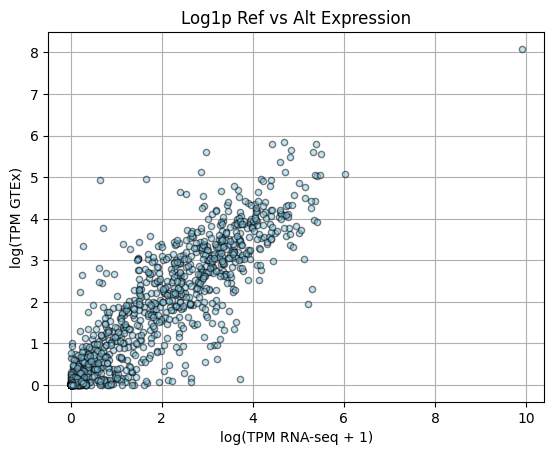

In [221]:
plt.scatter(np.log1p(targets_df["tpm_rna"]), np.log1p(targets_df["tpm_gtex"]), s=20, alpha=0.5, edgecolors="black", c="skyblue")
plt.xlabel('log(TPM RNA-seq + 1)')
plt.ylabel('log(TPM GTEx)')
plt.title('Log1p Ref vs Alt Expression')
plt.grid()
plt.gca().set_axisbelow(True)

### Figure 2.
This plot compares the variant gene expression from the RNA-seq dataset vs the reference gene expression from the GTEx dataset.
We see that most of the genes have similar expression.
Some RNA-seq genes are showing small amounts expression that previously showed none.
Also some reference genes that used to express are now not expressing anything.
However the newly expressing genes are still less than 1 in a million, which could be noise.
We don't see any genes that have had a large change in expression.

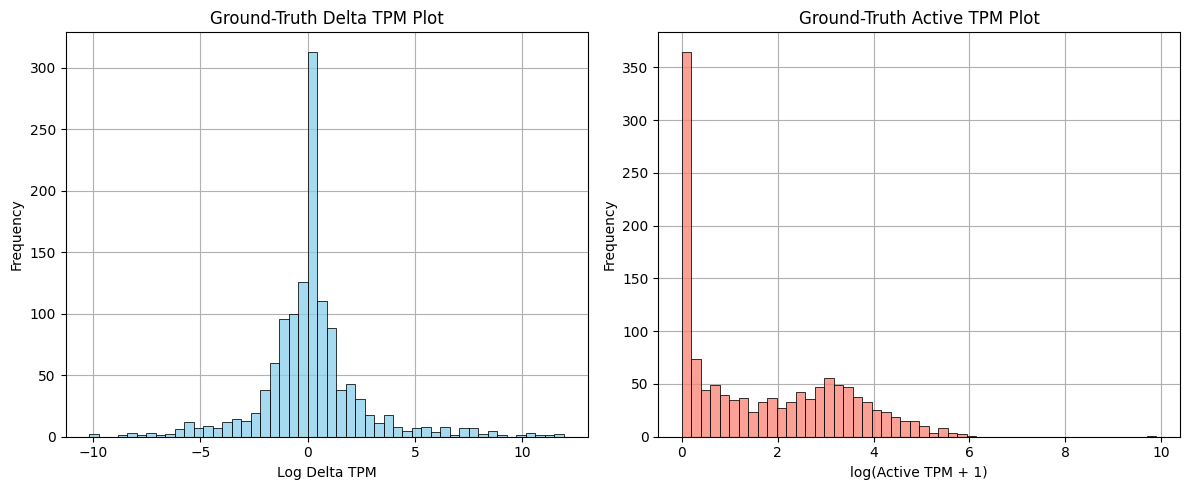

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(targets_df["delta_tpm"], bins=50, color="skyblue", edgecolor='black', ax=ax1)
ax1.set_title('Ground-Truth LFC TPM Plot')
ax1.set_xlabel('Log-fold change TPM')
ax1.set_ylabel('Count')
ax1.grid()
ax1.set_axisbelow(True)

sns.histplot(np.log1p(targets_df["active_tpm"]), bins=50, color="salmon", edgecolor='black')
ax2.set_title('Ground-Truth Active TPM Plot')
ax2.set_xlabel('log(Active TPM + 1)')
ax2.set_ylabel('Count')
ax2.grid()
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Figure 3.
The left plot show the ground-truth log fold-change calculated from the RNA-seq variant gene expression and the GTEx reference gene exrpession. 
The right plot shows the ground-truth active gene expression calculated from the max expression between each reference gene and its variant (alt).
These will make a good reference to compare our model's predictions.

**Ground Truth Log-fold Change TPM**

We see a Students long-tailed distribution centered around zero and ranges between -10 to 10.
Here positive values indicate an increase in expression of a gene with negative implying a decrese in expression.

**Ground Truth Active TPM**

This distribution matches the classic multi-modal RNA-seq log1p TPM distribution we see in the individual RNA-seq and GTE-x data with the two peaks at 0 and 3. This distribution is expected to match the underlying distributions as we expect most genes to have little variation, which we see in the left plot.

# Score Analysis

In [42]:
# Get the log-fold change RNA-seq scorers as they are closest to what we want
# CL:0002553 refers to Fibroblasts found in the lung
# UBERON:0002167 refers to tissue found in the right lung
# UBERON:0002167 refers to tissue found in the left lung
# UBERON:0008952 refers to tissue from both lungs
# GeneMaskLFCScorer is a log-fold RNA-seq log-fold change scorer
# GeneMaskActiveScorer is the max predicted expression of the two sequences
# We can actually get out the REF and ALT by combining the LFC and Active scorers
# LFC = log2(ALT) - log2(REF)
# Active = max(ALT, REF)
# If LFC >= 0, ALT = Active, REF = Active / 2^LFC
# If LFC < 0, ALT = Active * 2^LFC, REF = Active
alpha_scores_df[alpha_scores_df["score_id"].str.contains("RNA-seq")]["score_id"].unique().tolist()

['CL:0002553 polyA plus RNA-seq . GeneMaskLFCScorer NONE',
 'UBERON:0002167 polyA plus RNA-seq . GeneMaskLFCScorer NONE',
 'UBERON:0002168 polyA plus RNA-seq . GeneMaskLFCScorer NONE',
 'UBERON:0008952 gtex Lung polyA plus RNA-seq . GeneMaskLFCScorer NONE',
 'CL:0002553 polyA plus RNA-seq . GeneMaskActiveScorer NONE',
 'UBERON:0002167 polyA plus RNA-seq . GeneMaskActiveScorer NONE',
 'UBERON:0002168 polyA plus RNA-seq . GeneMaskActiveScorer NONE',
 'UBERON:0008952 gtex Lung polyA plus RNA-seq . GeneMaskActiveScorer NONE']

## Low Expression vs High Expression Performance

In [274]:
# Lets compare predictions for lung cells vs lung tissue and LFC vs Active
cols = ["gene_id", "raw_score"]
cell_lfc_scorer = "CL:0002553 polyA plus RNA-seq . GeneMaskLFCScorer NONE"
tissue_lfs_scorer = "UBERON:0008952 gtex Lung polyA plus RNA-seq . GeneMaskLFCScorer NONE"
cell_active_scorer = "CL:0002553 polyA plus RNA-seq . GeneMaskActiveScorer NONE"
tissue_active_scorer = "UBERON:0008952 gtex Lung polyA plus RNA-seq . GeneMaskActiveScorer NONE"

cell_lfc_scores_df = alpha_scores_df.loc[alpha_scores_df["score_id"] == cell_lfc_scorer, cols].merge(targets_df, on="gene_id", how="inner")
tissue_lfc_scores_df = alpha_scores_df.loc[alpha_scores_df["score_id"] == tissue_lfs_scorer, cols].merge(targets_df, on="gene_id", how="inner")
cell_active_scores_df = alpha_scores_df.loc[alpha_scores_df["score_id"] == cell_active_scorer, cols].merge(targets_df, on="gene_id", how="inner")
tissue_active_scores_df = alpha_scores_df.loc[alpha_scores_df["score_id"] == tissue_active_scorer, cols].merge(targets_df, on="gene_id", how="inner")
target_lfc_df, target_active_df = targets_df.copy(), targets_df.copy()
target_lfc_df["raw_score"] = target_lfc_df["delta_tpm"]
target_active_df["raw_score"] = target_active_df["active_tpm"]

cell_lfc_scores_df["sample_type"] = "Cell"
tissue_lfc_scores_df["sample_type"] = "Tissue"
target_lfc_df["sample_type"] = "Ground Truth"
cell_active_scores_df["sample_type"] = "Cell"
tissue_active_scores_df["sample_type"] = "Tissue"
target_active_df["sample_type"] = "Ground Truth"

lfc_scores_df = pd.concat([cell_lfc_scores_df, tissue_lfc_scores_df, target_lfc_df])
active_scores_df = pd.concat([cell_active_scores_df, tissue_active_scores_df, target_active_df])

len(cell_lfc_scores_df), len(tissue_lfc_scores_df), len(cell_active_scores_df), len(tissue_active_scores_df), len(lfc_scores_df), len(active_scores_df)

(1264, 1264, 1264, 1264, 3801, 3801)

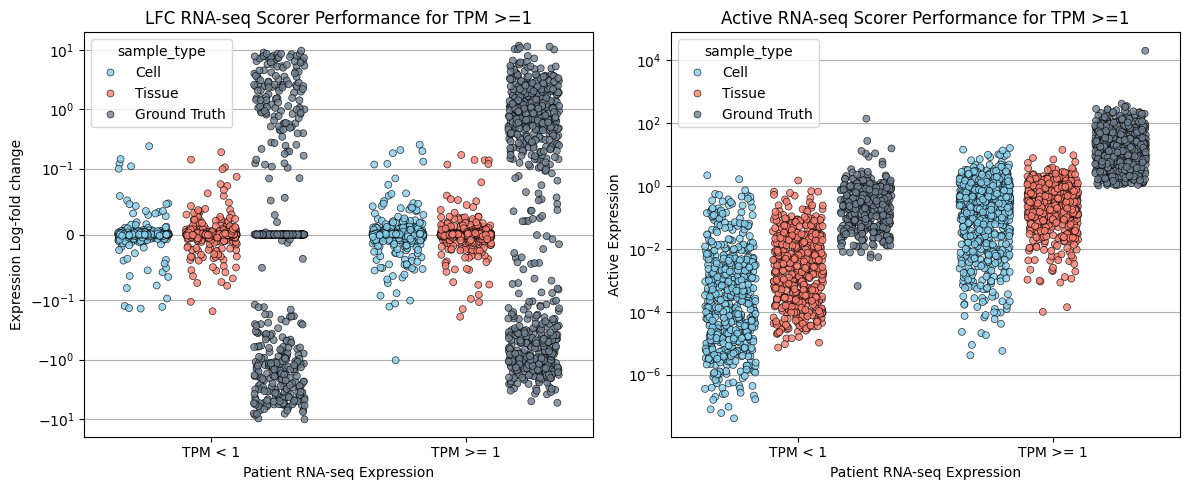

In [275]:
# Stratify patient RNA-seq into TPM > 1 and TPM <= 1
lfc_scores_df["tpm_group"] = (
    lfc_scores_df["tpm_rna"].ge(1).map({True: "TPM >= 1", False: "TPM < 1"})
)
active_scores_df["tpm_group"] = (
    active_scores_df["tpm_rna"].ge(1).map({True: "TPM >= 1", False: "TPM < 1"})
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
lfc_plot = sns.stripplot(
    data=lfc_scores_df,
    x="tpm_group", 
    y="raw_score", 
    hue="sample_type", 
    dodge=True,
    jitter=0.3,
    alpha=0.8,
    size=5,
    edgecolor="black",
    linewidth=0.5,
    order=["TPM < 1", "TPM >= 1"],
    hue_order=["Cell", "Tissue", "Ground Truth"],
    palette=["skyblue", "salmon", "slategray"],
    ax=ax1,
)
ax1.set_title("LFC RNA-seq Scorer Performance for TPM >=1")
ax1.set_ylabel("Expression Log-fold change")
ax1.set_xlabel("Patient RNA-seq Expression")
ax1.set_yscale('symlog', linthresh=0.1)
ax1.set_ylim(-20, 20)
ax1.grid(axis="y")
ax1.set_axisbelow(True)

lfc_plot = sns.stripplot(
    data=active_scores_df,
    x="tpm_group", 
    y="raw_score", 
    hue="sample_type", 
    dodge=True,
    jitter=0.3,
    alpha=0.8,
    size=5,
    edgecolor="black",
    linewidth=0.5,
    order=["TPM < 1", "TPM >= 1"],
    hue_order=["Cell", "Tissue", "Ground Truth"],
    palette=["skyblue", "salmon", "slategray"],
    ax=ax2,
)
ax2.set_title("Active RNA-seq Scorer Performance for TPM >=1")
ax2.set_ylabel("Active Expression")
ax2.set_xlabel("Patient RNA-seq Expression")
ax2.set_yscale('log')
ax2.grid(axis="y")
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Figure 4.
Here we explore the relationship between the underlying RNA-seq variant expression and the model prediction distributions.
The left strip plot compares the AlphaGenome predicted RNA-seq log-fold change scores where the ground-truth RNA-seq variant genes show expression with less than 1 TPM vs genes with expression more than 1 TPM. The RNA-seq scores are grouped by biosample, Fibroblast (cell) scorer vs the lung tissue scorer both contrasted against the underlying ground-truth data.
The right plot compares the same thing but using AlphaGenome's RNA-seq active expression scores.

**LFC Scoring**
* Here we see that generally the model predicts similar LFC scores regardless of low vs high expressing variants.
* The scale of the predictions tends to be quite conservative compared to ground truth log-fold change expression.
* The ground-truth data indicates that a lot of genes with zero expression will tend to keep zero expression, where as genes with higher expression are likely to be impacted by variants. Neither of the scores are able to capture this behaviour. 

**Active Scoring**
* Both the cell and tissue active scores correctly reflect that lower expression genes tend to stay lower and vice versa.
* Again the scale of the active predictions tends to be conservative relative to the real-world.

## Delta Expression Direction Performance

In [255]:
# Test whether variants predicted by AlphaGenome to reduce expression are associated with lower measured RNA expression
lfc_reduce_mask = lfc_scores_df['raw_score'] < -1e-3
lfc_increase_mask = lfc_scores_df['raw_score'] > 1e-3
lfc_scores_df['effect_group'] = np.select([lfc_reduce_mask, lfc_increase_mask], ['Reduces Expression', 'Increases Expression'], default='No Effect')
lfc_scores_df.groupby(["sample_type", "effect_group"])["tpm_rna"].agg([("Target RNA TPM", "median"), ("Sample", "count")]).loc[["Cell", "Tissue", "Ground Truth"]]

Target RNA TPM  Sample
sample_type  effect_group                                
Cell         Increases Expression         3.34070     363
             No Effect                    0.31870     569
             Reduces Expression           3.45905     332
Tissue       Increases Expression         1.22180     371
             No Effect                    3.41140     515
             Reduces Expression           1.86925     378
Ground Truth Increases Expression         7.80930     557
             No Effect                    0.00000     184
             Reduces Expression           2.11115     532

### Table 1.

Here we explore the relationship between the underlying RNA-seq variant expression and the models predicted log-fold change direction.
This table compares the median RNA-seq variant expression againt AlphaGenome's predicted log-fold change direction grouped by the cell type scorer and the predicted direction. We see that the fibroblast scorer's "No Effect" predictions are correctly associated with RNA-seq variant genes with low expression and the opposite for higher expression variant genes. Whereas the lung tissue scorers show the opposite pattern. When we compare this with the ground-truth delta log-fold change direction we see that the fibroblast scorer is closer to the real world, however it doesn't capture that increases in variant expression should be associated to a larger RNA TPM, and vice-vera for reductions in gene expression.


## Model Prediction Distributions

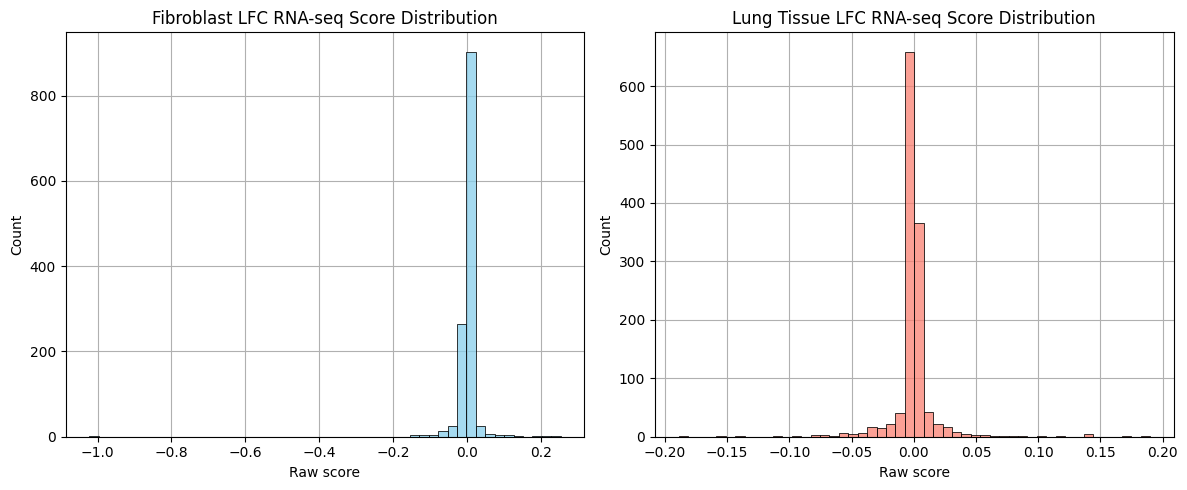

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(cell_lfc_scores_df["raw_score"], bins=50, color="skyblue", edgecolor='black', ax=ax1)
ax1.set_title('Fibroblast LFC RNA-seq Score Distribution')
ax1.set_xlabel('Raw score')
ax1.set_ylabel('Count')
ax1.grid()
ax1.set_axisbelow(True)

sns.histplot(tissue_lfc_scores_df["raw_score"], bins=50, color="salmon", edgecolor='black', ax=ax2)
ax2.set_title('Lung Tissue LFC RNA-seq Score Distribution')
ax2.set_xlabel('Raw score')
ax2.set_ylabel('Count')
ax2.grid()
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Figure 5.

The left plot shows the distribution of Fibroblast scorers' log-fold change predictions, whereas the right plot shows the distribution of the lung tissue scorer's log-fold change predictions. If we compare these with the ground-truth distributions in [Figure 3](#figure-3) we see that they have the correct distribution shape, but the model tends to make more conservative estimations of the log-fold change, which implies that the model might be underfitted, as it can't identify how small changes in DNA can impact expression.

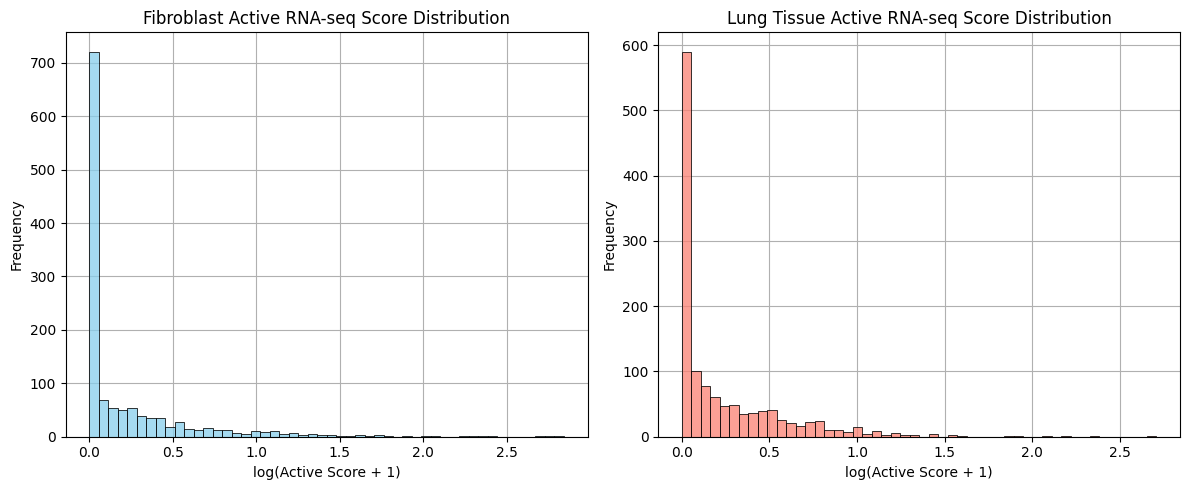

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(np.log1p(cell_active_scores_df["raw_score"]), bins=50, color="skyblue", edgecolor='black', ax=ax1)
ax1.set_title('Fibroblast Active RNA-seq Score Distribution')
ax1.set_xlabel('log(Active Score + 1)')
ax1.set_ylabel('Count')
ax1.grid()
ax1.set_axisbelow(True)

sns.histplot(np.log1p(tissue_active_scores_df["raw_score"]), bins=50, color="salmon", edgecolor='black', ax=ax2)
ax2.set_title('Lung Tissue Active RNA-seq Score Distribution')
ax2.set_xlabel('log(Active Score + 1)')
ax2.set_ylabel('Count')
ax2.grid()
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Figure 6.

The left plot shows the distribution of Fibroblast scorers' active expression predictions, whereas the right plot shows the distribution of the lung tissue scorer's active expression predictions. If we compare these to the ground-truth active expression in [Figure 3](#figure-3) we again see a similar distribution to the ground-truth active expression. However, the second peak indicating the higher expressing genes seems to be missing, indicating that the model assumes most of the genes have lower expression.

## Model Predictions vs Ground-truth Log-fold Change Expression

/var/folders/fx/6bgnspf57wj1hz1g80_7zw_00000gn/T/ipykernel_35587/2076279655.py:3: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.scatterplot(
/var/folders/fx/6bgnspf57wj1hz1g80_7zw_00000gn/T/ipykernel_35587/2076279655.py:23: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.scatterplot(


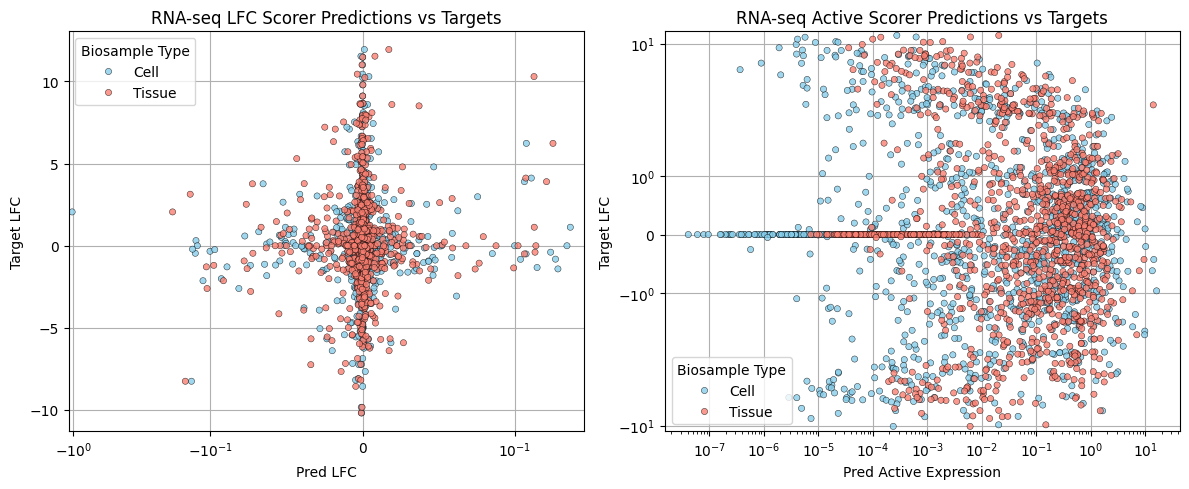

In [303]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    data=pd.concat([cell_lfc_scores_df, tissue_lfc_scores_df]), 
    x="raw_score", 
    y="delta_tpm", 
    hue="sample_type",
    palette=["skyblue", "salmon", "slategrey"],
    hue_order=["Cell", "Tissue"],
    edgecolors="black",
    s=20,
    alpha=0.8,
    ax=ax1
)
ax1.set_xscale('symlog', linthresh=0.1)
ax1.legend(title="Biosample Type")
ax1.set_xlabel('Pred LFC')
ax1.set_ylabel('Target LFC')
ax1.set_title('RNA-seq LFC Scorer Predictions vs Targets')
ax1.grid()
ax1.set_axisbelow(True)

sns.scatterplot(
    data=pd.concat([cell_active_scores_df, tissue_active_scores_df]), 
    x="raw_score", 
    y="delta_tpm", 
    hue="sample_type",
    palette=["skyblue", "salmon", "slategrey"],
    hue_order=["Cell", "Tissue"],
    edgecolors="black",
    s=20,
    alpha=0.8,
    ax=ax2
)
ax2.set_xscale('log')
ax2.set_yscale('symlog')
ax2.legend(title="Biosample Type")
ax2.set_xlabel('Pred Active Expression')
ax2.set_ylabel('Target LFC')
ax2.set_title('RNA-seq Active Scorer Predictions vs Targets')
ax2.grid()
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Figure 7

Here we compare the AlphaGenomes Scorers' predictions against the ground-truth log-fold change to find a predictive signal we can use to identify lower expressing genes.
The left plot shows the predicted log-fold change score against the ground-truth comparing the fibroblast vs lung tissue scorers. We see no correlation between the model predictions and the ground-truth, meaning the model is unable to predict how a gene variant will change gene expression.  The right plot compares the predicted active expression score against the ground-truth log-fold expression change comparing the fibroblast vs lung tissue scorers. We see that genes predicted to have low active expression tend to have ground-truth LFC's close to zero. This could be used to identify gene variants that are likely to have no change in expression.

## Low Expression Classification Performance

In [354]:
score_thresholds = [
    ("CL:0002553 polyA plus RNA-seq . GeneMaskActiveScorer NONE", 1e-4),
    ("UBERON:0008952 gtex Lung polyA plus RNA-seq . GeneMaskActiveScorer NONE", 1e-3),
]
track_metrics = []
for score_id, threshold in score_thresholds:
    group_df = alpha_scores_df[alpha_scores_df["score_id"] == score_id]
    group_df = group_df.merge(targets_df, on="gene_id", how="inner")
    pred_label, target_label = np.abs(group_df["raw_score"]) > threshold, np.abs(group_df["delta_tpm"]) > threshold
    track_metrics.append({
        "score_id": score_id,
        "threshold": threshold,
        "n": len(group_df),
        "pred_pos_n": pred_label.sum(),
        "pred_neg_n": len(group_df) - pred_label.sum(),
        "target_pos_n": target_label.sum(),
        "target_neg_n": len(group_df) - target_label.sum(),
        "acc": accuracy_score(target_label, pred_label),
        "precision": precision_score(target_label, pred_label),
        "recall": recall_score(target_label, pred_label),
        "auPRC": average_precision_score(target_label, pred_label),
        "matthews": matthews_corrcoef(target_label, pred_label),
    })

metrics_df = pd.DataFrame(track_metrics)
metrics_df.sort_values("auPRC", ascending=False)

,score_id,threshold,n,pred_pos_n,pred_neg_n,target_pos_n,target_neg_n,acc,precision,recall,auPRC,matthews
1,UBERON:0008952 gtex Lung polyA plus RNA-seq . ...,0.0010,1264,1050,214,1083,181,0.905854,0.959048,0.929825,0.951873,0.646574
0,CL:0002553 polyA plus RNA-seq . GeneMaskActive...,0.0001,1264,1016,248,1085,179,0.875791,0.956693,0.895853,0.946455,0.570703


### Table 2.

Based on the insights of [Figure 7](#figure-7) we identify a  classification threshold of 1e-4 and 1e-3 for the fibroblast active scorer and the lung tissue active scorer respectively. We see that both of the biosample scorers show strong predictive capabilities at identifying gene variants that are likely to have a LFC greather than their threshold, with the lung tissue scorer showing slightly better performance. However, the lower Matthews correlation on both of the scorers shows that neither of the models are as strong on the negative case. They struggle more to indentify gene variants will have LFC smaller than their threshold.

# Evaluating Ref and Alt Predictions

In [51]:
# Calculate original REF and ALT scores
cell_ref_alt_df = (
    cell_lfc_scores_df[["gene_id", "raw_score"]]
    .rename(columns={"raw_score": "lfc_score"})
    .merge(cell_active_scores_df[["gene_id", "raw_score"]].rename(columns={"raw_score": "active_score"}), on="gene_id", how="inner")
)
tissue_ref_alt_df = (
    tissue_lfc_scores_df[["gene_id", "raw_score"]]
    .rename(columns={"raw_score": "lfc_score"})
    .merge(tissue_active_scores_df[["gene_id", "raw_score"]].rename(columns={"raw_score": "active_score"}), on="gene_id", how="inner")
)

cell_ref_alt_df["ref_score"] = np.where(cell_ref_alt_df['lfc_score'] >= 0, cell_ref_alt_df['active_score'] / (2 ** cell_ref_alt_df['lfc_score']), cell_ref_alt_df['active_score'])
cell_ref_alt_df["alt_score"] = np.where(cell_ref_alt_df['lfc_score'] >= 0, cell_ref_alt_df['active_score'], cell_ref_alt_df['active_score'] * (2 ** cell_ref_alt_df['lfc_score']))
tissue_ref_alt_df["ref_score"] = np.where(tissue_ref_alt_df['lfc_score'] >= 0, tissue_ref_alt_df['active_score'] / (2 ** tissue_ref_alt_df['lfc_score']), tissue_ref_alt_df['active_score'])
tissue_ref_alt_df["alt_score"] = np.where(tissue_ref_alt_df['lfc_score'] >= 0, tissue_ref_alt_df['active_score'], tissue_ref_alt_df['active_score'] * (2 ** tissue_ref_alt_df['lfc_score']))

# Merge targets with scores just for the validation targets with single variants
cell_ref_alt_df = cell_ref_alt_df.merge(targets_df, on="gene_id", how="inner")
tissue_ref_alt_df = tissue_ref_alt_df.merge(targets_df, on="gene_id", how="inner")

## Predicted RNA-seq Reference vs Alternative Expression Performance 

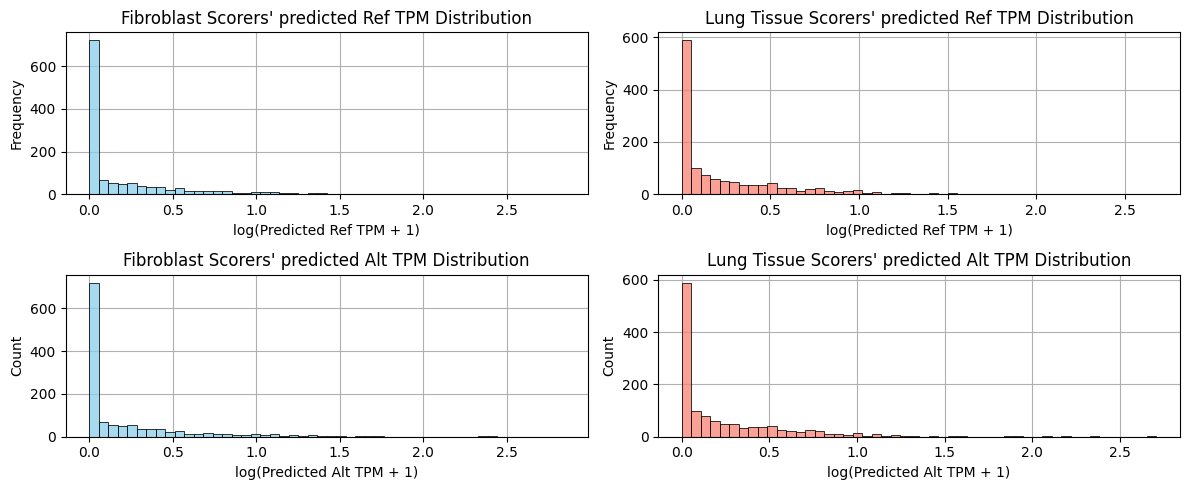

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 5))

sns.histplot(np.log1p(cell_ref_alt_df["ref_score"]), bins=50, color="skyblue", edgecolor='black', ax=ax1)
ax1.set_title('Fibroblast Scorers\' predicted Ref TPM Distribution')
ax1.set_xlabel('log(Predicted Ref TPM + 1)')
ax1.set_ylabel('Count')
ax1.grid()
ax1.set_axisbelow(True)

sns.histplot(np.log1p(tissue_ref_alt_df["ref_score"]), bins=50, color="salmon", edgecolor='black', ax=ax2)
ax2.set_title('Lung Tissue Scorers\' predicted Ref TPM Distribution')
ax2.set_xlabel('log(Predicted Ref TPM + 1)')
ax2.set_ylabel('Count')
ax2.grid()
ax2.set_axisbelow(True)

sns.histplot(np.log1p(cell_ref_alt_df["alt_score"]), bins=50, color="skyblue", edgecolor='black', ax=ax3)
ax3.set_title('Fibroblast Scorers\' predicted Alt TPM Distribution')
ax3.set_xlabel('log(Predicted Alt TPM + 1)')
ax3.set_ylabel('Count')
ax3.grid()
ax3.set_axisbelow(True)

sns.histplot(np.log1p(tissue_ref_alt_df["alt_score"]), bins=50, color="salmon", edgecolor='black', ax=ax4)
ax4.set_title('Lung Tissue Scorers\' predicted Alt TPM Distribution')
ax4.set_xlabel('log(Predicted Alt TPM + 1)')
ax4.set_ylabel('Count')
ax4.grid()
ax4.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Figure 8

Using both the active and LFC scores for a given biosample track we are able to recalculate the predicted reference and variant (alt) gene expression. The top left and bottom left plots show the fibroblast's predicted log(tpm + 1) for the reference and variants expression respectively. The top right and bottom right plots show the lung tissue's predicted log(tpm + 1) for the reference and variants expression respectively. We see the same log(TPM + 1) distribution we saw in [Figure 6](#figure-6) with the second peak missing for all plots.

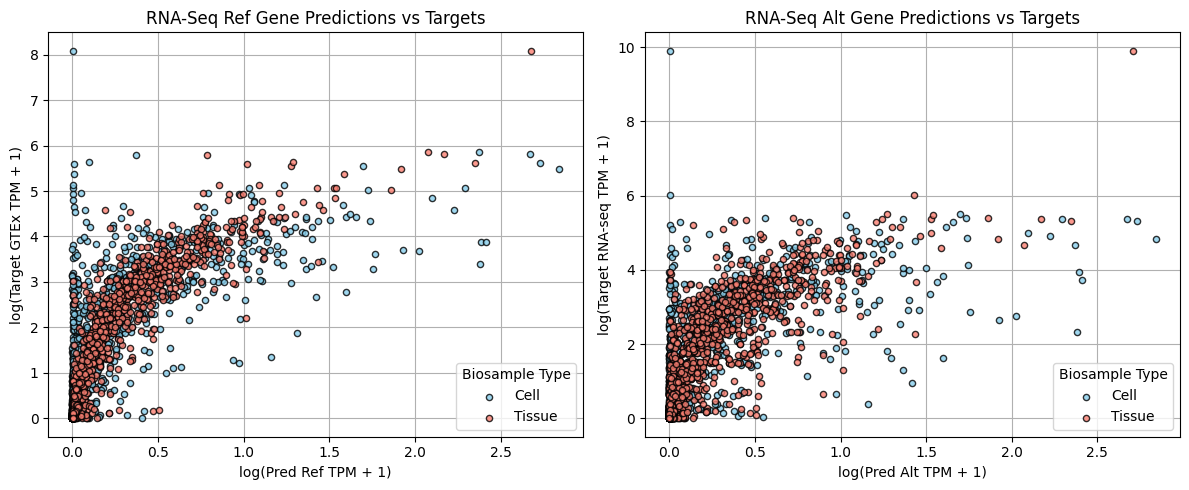

In [358]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(np.log1p(cell_ref_alt_df["ref_score"]), np.log1p(cell_ref_alt_df["tpm_gtex"]), c="skyblue", s=20, alpha=0.8, edgecolors="black", label="Cell")
ax1.scatter(np.log1p(tissue_ref_alt_df["ref_score"]), np.log1p(tissue_ref_alt_df["tpm_gtex"]), c="salmon", s=20, alpha=0.8, edgecolors="black", label="Tissue")
# ax1.set_xscale('symlog', linthresh=0.001)
# ax1.set_yscale('symlog', linthresh=0.001)
ax1.legend(title="Biosample Type")
ax1.set_xlabel('log(Pred Ref TPM + 1)')
ax1.set_ylabel('log(Target GTEx TPM + 1)')
ax1.set_title('RNA-Seq Ref Gene Predictions vs Targets')
ax1.grid()
ax1.set_axisbelow(True)

ax2.scatter(np.log1p(cell_ref_alt_df["alt_score"]), np.log1p(cell_ref_alt_df["tpm_rna"]), c="skyblue", s=20, alpha=0.8, edgecolors="black", label="Cell")
ax2.scatter(np.log1p(tissue_ref_alt_df["alt_score"]), np.log1p(tissue_ref_alt_df["tpm_rna"]), c="salmon", s=20, alpha=0.8, edgecolors="black", label="Tissue")
# ax2.set_xscale('symlog', linthresh=0.001)
# ax2.set_yscale('symlog', linthresh=0.001)
ax2.legend(title="Biosample Type")
ax2.set_xlabel('log(Pred Alt TPM + 1)')
ax2.set_ylabel('log(Target RNA-seq TPM + 1)')
ax2.set_title('RNA-Seq Alt Gene Predictions vs Targets')
ax2.grid()
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Figure 9

We compare the models reference and variant TPM expression predictions against the ground-truth targets.
The left plot compares the reference predictions against the GTEx TPM data, and the right plot compares the variant (alt) prediction against the ground-truth RNA-seq variant data.


In [53]:
# We see that actually the model is very good at predicting the alt and reference
corr_pd = pd.concat([
    pg.corr(cell_ref_alt_df["ref_score"], cell_ref_alt_df["tpm_gtex"], method="spearman"),
    pg.corr(tissue_ref_alt_df["ref_score"], tissue_ref_alt_df["tpm_gtex"], method="spearman"),
    pg.corr(cell_ref_alt_df["alt_score"], tissue_ref_alt_df["tpm_rna"], method="spearman"),
    pg.corr(tissue_ref_alt_df["alt_score"], tissue_ref_alt_df["tpm_rna"], method="spearman"),
])
corr_pd.index = ["Fibroblast Ref", "Lung Tissue Ref", "Fibroblast Alt", "Lung Tissue Alt"]
corr_pd[["n", "r", "p_val", "power"]].rename(columns={"n": "Samples", "r": "Spearman", "p_val": "P-value", "power": "Power"})

,Samples,Spearman,P-value,Power
Fibroblast Ref,1264,0.855720,0.0,1.0
Lung Tissue Ref,1264,0.949943,0.0,1.0
Fibroblast Alt,1264,0.824681,0.0,1.0
Lung Tissue Alt,1264,0.883464,0.0,1.0


### Table 3.

This table shows the correlations between the the fibroblast and lung tissue track scores for the reference and variant (alt) genes vs the ground-truth values from the GTEx and RNA-seq variant datasets respectively. We see a stong correlation between the model ref/alt scores and the ground-truth data, indicating the model is able to capture the general expression profile of genes in the hg38 reference dataset. However, the poor performance on the log-fold change predictions against the ground-truth log-fold change indicates that the model is underfitted and unable to identify so small variations to a gene can impact expression.